# BigMart Sales Classification — Accurate & Runnable Notebook

## Objective
Convert the original BigMart sales regression problem into a binary classification task:

- **0 = Low Sales**
- **1 = High Sales**

The classification threshold is calculated from the **training set only** to avoid test-set information leaking into model development.

## Workflow
1. Load and inspect data
2. Clean inconsistent categorical values
3. Engineer useful features
4. Create the binary target using the training-set median
5. Remove leakage-prone/original target columns
6. Build preprocessing pipelines
7. Train five classification models
8. Evaluate Accuracy, Precision, Recall, F1 and ROC-AUC
9. Plot confusion matrix and ROC curves
10. Perform stratified cross-validation for the best model

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("Train.csv")
print("Dataset shape:", df.shape)
display(df.head())
print("\nMissing values:")
display(df.isna().sum().to_frame("Missing"))

Dataset shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052



Missing values:


,Missing
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


## 1. Data Cleaning and Feature Engineering

- Standardize known inconsistent `Item_Fat_Content` labels.
- Treat zero `Item_Visibility` as missing-like values.
- Create `New_Item_Type` from the first two characters of `Item_Identifier`.
- Create `Outlet_Years` from outlet establishment year.

In [3]:
data = df.copy()

data["Item_Fat_Content"] = data["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})

data["Item_Visibility"] = data["Item_Visibility"].replace(0, np.nan)

data["New_Item_Type"] = data["Item_Identifier"].str[:2]

latest_year = data["Outlet_Establishment_Year"].max()
data["Outlet_Years"] = latest_year - data["Outlet_Establishment_Year"]

display(data.head())

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,New_Item_Type,Outlet_Years
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,FD,10
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,DR,0
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,FD,10
3,FDX07,19.20,Regular,NaN,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800,FD,11
4,NCD19,8.93,Low Fat,NaN,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,NC,22


## 2. Train/Test Split and Leakage-Safe Target Creation

The original `Item_Outlet_Sales` is the continuous sales value. The classification threshold is calculated from the **training portion only**.

The test set is then labelled using that fixed training threshold.

In [4]:
# Temporary labels are used only to make the split reasonably balanced.
temporary_threshold = data["Item_Outlet_Sales"].median()
temporary_y = (data["Item_Outlet_Sales"] >= temporary_threshold).astype(int)

train_data, test_data = train_test_split(
    data,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=temporary_y
)

# Correct threshold: training-set median only.
sales_threshold = train_data["Item_Outlet_Sales"].median()

train_data = train_data.copy()
test_data = test_data.copy()

train_data["Sales_Class"] = (train_data["Item_Outlet_Sales"] >= sales_threshold).astype(int)
test_data["Sales_Class"] = (test_data["Item_Outlet_Sales"] >= sales_threshold).astype(int)

print(f"Training-set median sales threshold: {sales_threshold:.2f}")
print("\nTraining class distribution:")
display(train_data["Sales_Class"].value_counts().sort_index())

print("\nTest class distribution:")
display(test_data["Sales_Class"].value_counts().sort_index())

Training-set median sales threshold: 1794.33

Training class distribution:


Sales_Class
0    3405
1    3413
Name: count, dtype: int64


Test class distribution:


Sales_Class
0    852
1    853
Name: count, dtype: int64

## 3. Prepare Features

`Item_Outlet_Sales` is removed because it directly defines the target and would cause target leakage.

Raw `Item_Identifier` and `Outlet_Identifier` are also removed from the model. Their engineered/meaningful information is retained through other features.

In [5]:
if "train_data" not in globals() or "test_data" not in globals():
    # Safety fallback: create the split if this cell is run before the split cell.
    temporary_threshold = data["Item_Outlet_Sales"].median()
    temporary_y = (data["Item_Outlet_Sales"] >= temporary_threshold).astype(int)

    train_data, test_data = train_test_split(
        data,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=temporary_y
    )

    sales_threshold = train_data["Item_Outlet_Sales"].median()

    train_data = train_data.copy()
    test_data = test_data.copy()

    train_data["Sales_Class"] = (train_data["Item_Outlet_Sales"] >= sales_threshold).astype(int)
    test_data["Sales_Class"] = (test_data["Item_Outlet_Sales"] >= sales_threshold).astype(int)

# Prepare the feature matrix and target.
drop_columns = [
    "Item_Outlet_Sales",
    "Sales_Class",
    "Item_Identifier",
    "Outlet_Identifier"
]

X_train = train_data.drop(columns=drop_columns)
y_train = train_data["Sales_Class"]

X_test = test_data.drop(columns=drop_columns)
y_test = test_data["Sales_Class"]

categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'New_Item_Type']
Numeric features: ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Outlet_Years']


## 4. Preprocessing Pipeline

Numeric features use median imputation and standard scaling. Categorical features use most-frequent imputation and one-hot encoding.

Keeping preprocessing inside a scikit-learn pipeline prevents preprocessing leakage.

In [6]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 5. Train Classification Models

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Extra Trees
5. Gradient Boosting

In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=5, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=3,
        random_state=RANDOM_STATE
    )
}

results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })
    fitted_models[name] = pipe

results_df = (
    pd.DataFrame(results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8176,0.8226,0.8101,0.8163,0.9005
1,Gradient Boosting,0.8182,0.7929,0.8617,0.8258,0.8995
2,Random Forest,0.8194,0.7952,0.8605,0.8266,0.8882
3,Decision Tree,0.8135,0.7855,0.8628,0.8223,0.8880
4,Extra Trees,0.8111,0.7966,0.8359,0.8158,0.8870


## 6. Model Comparison

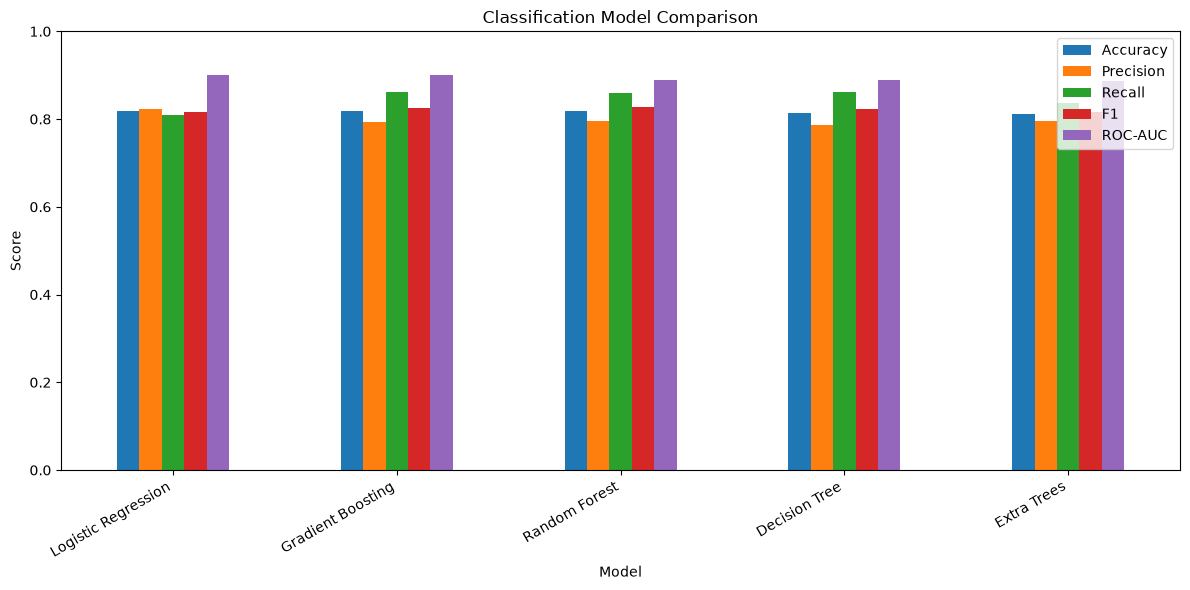

In [8]:
ax = results_df.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"
]].plot(kind="bar", figsize=(12, 6))

ax.set_title("Classification Model Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 7. Best Model Evaluation

In [9]:
best_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_name]

best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:, 1]

print("Best model by ROC-AUC:", best_name)
print("\nClassification Report:")
print(classification_report(
    y_test, best_pred,
    target_names=["Low Sales", "High Sales"],
    zero_division=0
))

Best model by ROC-AUC: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

   Low Sales       0.81      0.83      0.82       852
  High Sales       0.82      0.81      0.82       853

    accuracy                           0.82      1705
   macro avg       0.82      0.82      0.82      1705
weighted avg       0.82      0.82      0.82      1705



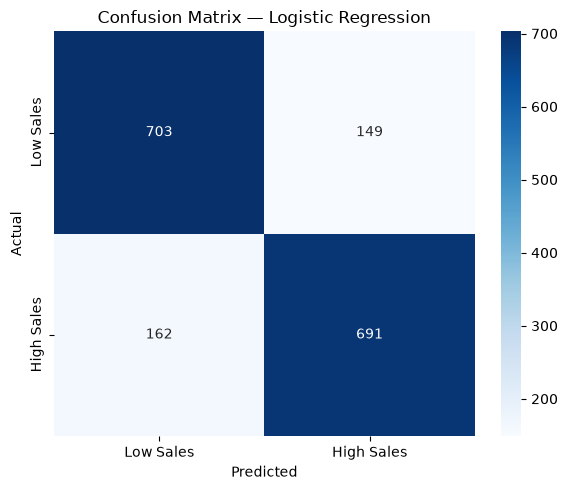

In [10]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Low Sales", "High Sales"],
    yticklabels=["Low Sales", "High Sales"]
)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 8. ROC Curves for All Models

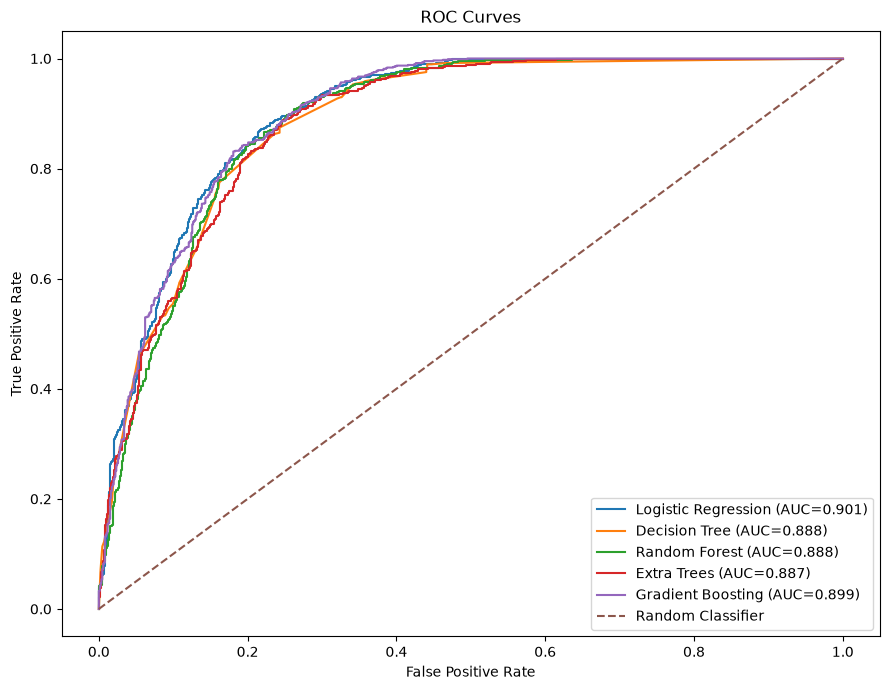

In [11]:
plt.figure(figsize=(9, 7))

for name, pipe in fitted_models.items():
    prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Stratified Cross-Validation for the Best Model

Five-fold stratified cross-validation is performed on the training data only.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_auc = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("5-Fold CV ROC-AUC scores:", np.round(cv_auc, 4))
print(f"Mean CV ROC-AUC: {cv_auc.mean():.4f}")
print(f"Std CV ROC-AUC: {cv_auc.std():.4f}")

5-Fold CV ROC-AUC scores: [0.904  0.8926 0.8869 0.8858 0.911 ]
Mean CV ROC-AUC: 0.8960
Std CV ROC-AUC: 0.0099


In [13]:
results_df.to_csv("classification_model_results.csv", index=False)
print("Saved: classification_model_results.csv")

Saved: classification_model_results.csv


## Final Conclusion

This is a valid binary classification reformulation of the BigMart Sales problem.

### Correctness points
- The original sales target is not used as a predictor.
- The classification threshold is calculated from training data only.
- Preprocessing is inside scikit-learn pipelines.
- Multiple classification algorithms are compared.
- The held-out test set is used only for final evaluation.
- Cross-validation is performed on training data.

**Important:** This predicts Low/High sales class from product and outlet attributes. It is not a time-series forecasting project.